# 04b — Correlation analysis: City vs Resort

Cùng trình tự notebook **04** (Pearson, Spearman, Cramér's V, heatmap, partial correlation,
phân loại causation vs leakage), nhưng **tính riêng từng hotel** rồi so sánh ranking / effect.

1. Snapshot volume / tỷ lệ hủy
2. Pearson + Spearman mọi biến số vs `is_canceled`
3. Cramér's V biến phân loại (`hotel` hằng số → bỏ)
4. Heatmap Pearson (loại leakage)
5. Heatmap 1 cột mọi biến then chốt vs target
6. Leakage
7. Partial correlation `lead_time` ↔ `deposit_type`
8. Causation vs correlation — tier có thể khác nhau giữa 2 hotel

**Nguồn:** `hotel_bookings_v5.csv` · giữ cả booking hủy.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.linalg import lstsq
from scipy.stats import chi2_contingency, pearsonr, spearmanr

%matplotlib inline
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "04b"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HOTELS = ["City Hotel", "Resort Hotel"]
HOTEL_COLORS = {"City Hotel": "#4C72B0", "Resort Hotel": "#55A868"}
TARGET = "is_canceled"
LEAK_NUM = ["revenue", "Occupancy_Rate", "RevPAR"]
LEAK_CAT = ["reservation_status", "reservation_status_date"]
DEP_MAP = {"No Deposit": 0, "Refundable": 1, "Non Refund": 2}
SKIP_NUM = set(LEAK_NUM + ["dep_enc"])
SKIP_CAT = set(LEAK_CAT + ["hotel"])
KEY_NUM = [
    "lead_time", "required_car_parking_spaces", "total_of_special_requests",
    "adr", "booking_changes", "is_repeated_guest", "previous_cancellations",
    "total_nights", "stays_in_week_nights", "adults", "children",
    "previous_bookings_not_canceled",
]
KEY_CAT = [
    "market_segment", "deposit_type", "distribution_channel", "customer_type",
    "assigned_room_type", "arrival_date_month", "reserved_room_type",
    "meal", "day_of_week", "country",
]

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")


ROOT: C:\Users\ADMIN\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: C:\Users\ADMIN\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: C:\Users\ADMIN\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\04b


In [2]:
def savefig(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def cramers_v(x, y) -> float:
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, k = tab.shape
    return float(np.sqrt(chi2 / (n * min(r - 1, k - 1))))


def partial_corr(x: str, y: str, controls: list[str], data: pd.DataFrame) -> float:
    cols = [x, y, *controls]
    sub = data[cols].dropna()
    if len(sub) < 10:
        return np.nan

    def residuals(var: str, others: list[str]) -> np.ndarray:
        X = np.column_stack([np.ones(len(sub)), sub[others].values])
        beta = lstsq(X, sub[var].values, rcond=None)[0]
        return sub[var].values - X @ beta

    rx = residuals(x, controls)
    ry = residuals(y, controls)
    return float(np.corrcoef(rx, ry)[0, 1])


def corr_tables(d: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    d = d.copy()
    num_cols = [c for c in d.select_dtypes(include=[np.number]).columns if c != TARGET]
    cat_cols = [
        c for c in d.select_dtypes(include=["object", "category", "bool"]).columns
        if c not in SKIP_CAT
    ]
    rows = []
    for c in num_cols:
        if c in SKIP_NUM:
            continue
        sub = d[[c, TARGET]].dropna()
        if len(sub) < 10 or sub[c].nunique() < 2:
            continue
        r, _ = pearsonr(sub[c], sub[TARGET])
        rho, _ = spearmanr(sub[c], sub[TARGET])
        rows.append({"variable": c, "pearson": r, "spearman": rho, "abs_r": abs(r)})
    pear = pd.DataFrame(rows).sort_values("abs_r", ascending=False)
    crow = [{"variable": c, "cramers_v": cramers_v(d[c], d[TARGET])} for c in cat_cols]
    cram = pd.DataFrame(crow).sort_values("cramers_v", ascending=False)
    return pear, cram


In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df["hotel"] = pd.Categorical(df["hotel"], categories=HOTELS, ordered=True)
print(f"Tong booking: {len(df):,} | ty le huy: {df[TARGET].mean():.2%}")
for h in HOTELS:
    g = df[df["hotel"] == h]
    print(f"  {h}: n={len(g):,} | huy={g[TARGET].mean():.2%} | canceled={int(g[TARGET].sum()):,}")


Tong booking: 82,811 | ty le huy: 28.12%
  City Hotel: n=50,686 | huy=30.68% | canceled=15,549
  Resort Hotel: n=32,125 | huy=24.08% | canceled=7,735


## 0. Snapshot


,hotel,bookings,canceled,cancel_rate
0,City Hotel,"50,686","15,549",30.7%
1,Resort Hotel,"32,125","7,735",24.1%


Saved: reports\figures\04b\00_snapshot.png


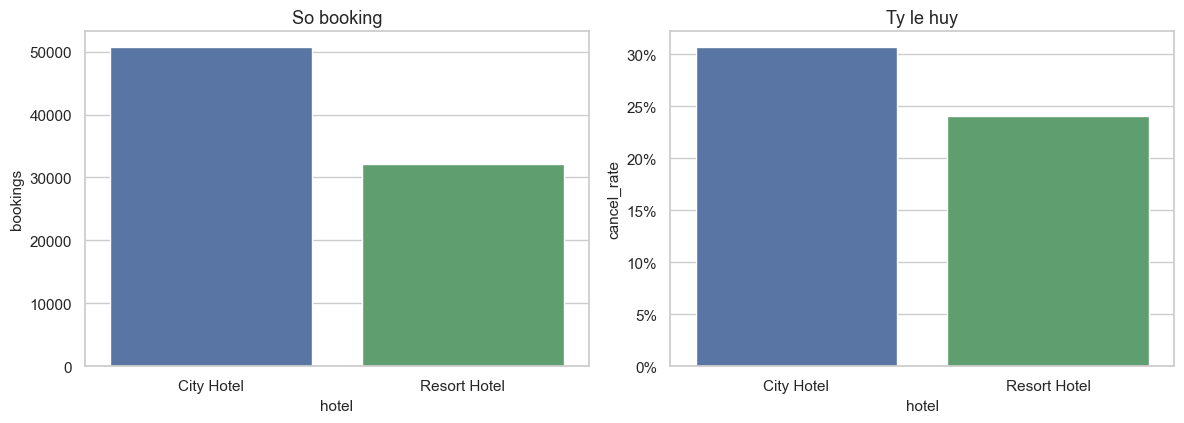

In [4]:
snap = (
    df.groupby("hotel", observed=True)[TARGET]
    .agg(bookings="count", canceled="sum", cancel_rate="mean")
    .reindex(HOTELS)
    .reset_index()
)
display(snap.style.format({"bookings": "{:,.0f}", "canceled": "{:,.0f}", "cancel_rate": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.barplot(data=snap, x="hotel", y="bookings", hue="hotel", palette=HOTEL_COLORS, ax=axes[0], legend=False)
axes[0].set_title("So booking")
sns.barplot(data=snap, x="hotel", y="cancel_rate", hue="hotel", palette=HOTEL_COLORS, ax=axes[1], legend=False)
axes[1].set_title("Ty le huy")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
savefig("00_snapshot.png")
plt.show()


## 1. Tương quan biến số (Pearson & Spearman)

Tính **riêng từng hotel**. Leakage (`revenue`, `Occupancy_Rate`, `RevPAR`) không đưa vào bảng ranking.
`dep_enc` chỉ dùng cho partial correlation, không xếp hạng Pearson.


In [5]:
tables = {}
for h in HOTELS:
    pear, cram = corr_tables(df[df["hotel"] == h])
    tables[h] = {"pearson": pear, "cramers": cram}
    print(f"\n=== {h} — Top Pearson vs is_canceled ===")
    display(pear.head(12).style.format({"pearson": "{:.3f}", "spearman": "{:.3f}", "abs_r": "{:.3f}"}))



=== City Hotel — Top Pearson vs is_canceled ===


,variable,pearson,spearman,abs_r
0,lead_time,0.204,0.226,0.204
17,total_of_special_requests,-0.170,-0.182,0.170
16,required_car_parking_spaces,-0.129,-0.129,0.129
18,total_nights,0.110,0.094,0.110
5,stays_in_week_nights,0.109,0.093,0.109
12,booking_changes,-0.091,-0.127,0.091
1,arrival_date_year,0.082,0.080,0.082
15,adr,0.081,0.095,0.081
6,adults,0.079,0.082,0.079
9,is_repeated_guest,-0.075,-0.075,0.075



=== Resort Hotel — Top Pearson vs is_canceled ===


,variable,pearson,spearman,abs_r
16,required_car_parking_spaces,-0.244,-0.248,0.244
0,lead_time,0.193,0.244,0.193
15,adr,0.168,0.166,0.168
13,agent,0.161,0.087,0.161
7,children,0.119,0.110,0.119
9,is_repeated_guest,-0.105,-0.105,0.105
18,total_nights,0.093,0.128,0.093
5,stays_in_week_nights,0.091,0.119,0.091
12,booking_changes,-0.090,-0.111,0.090
1,arrival_date_year,0.087,0.088,0.087


Saved: reports\figures\04b\01_pearson_compare.png


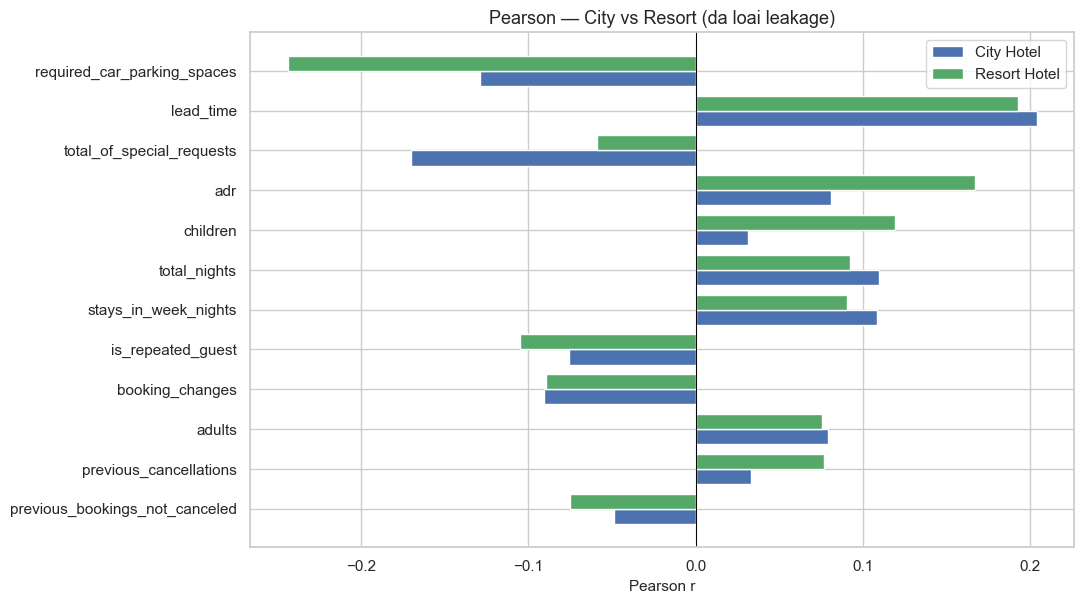

In [6]:
rows = []
for h in HOTELS:
    t = tables[h]["pearson"]
    for _, r in t.iterrows():
        if r["variable"] in KEY_NUM:
            rows.append({"hotel": h, "variable": r["variable"], "r": r["pearson"], "rho": r["spearman"]})
pear_df = pd.DataFrame(rows)
order = (
    pear_df.groupby("variable")["r"].apply(lambda s: s.abs().max())
    .sort_values(ascending=True).index.tolist()
)
y = np.arange(len(order))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 6.2))
for i, h in enumerate(HOTELS):
    vals = [pear_df[(pear_df.hotel == h) & (pear_df.variable == v)]["r"].iloc[0] for v in order]
    ax.barh(y + (i - 0.5) * w, vals, height=w, color=HOTEL_COLORS[h], label=h)
ax.axvline(0, color="black", lw=0.7)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel("Pearson r")
ax.set_title("Pearson — City vs Resort (da loai leakage)")
ax.legend()
savefig("01_pearson_compare.png")
plt.show()


Saved: reports\figures\04b\02_spearman_compare.png


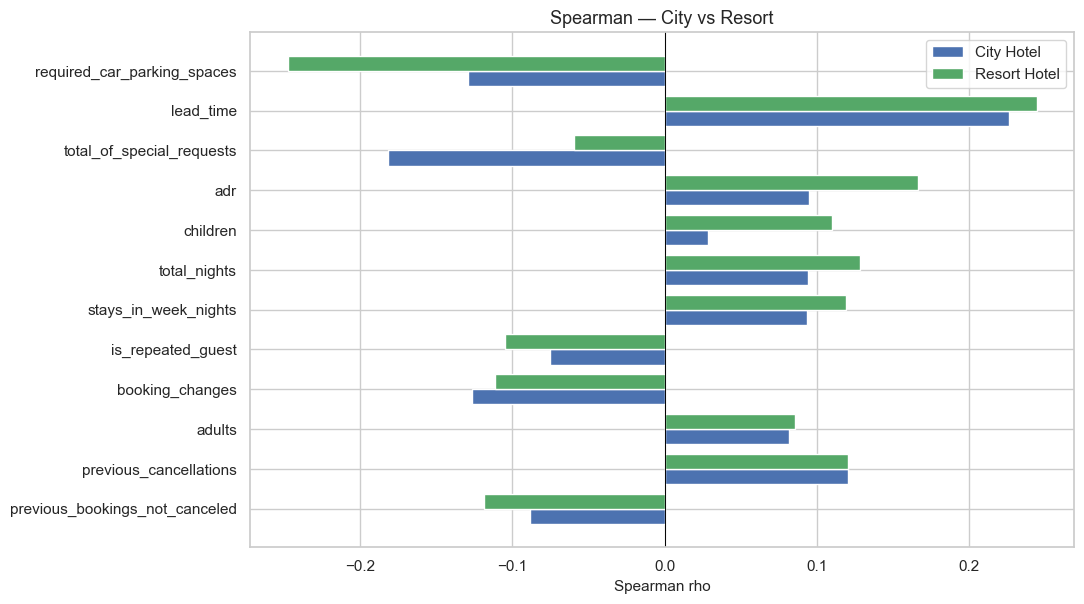

previous_cancellations: Pearson yeu, Spearman ~0.12 ca hai hotel (hieu ung o duoi).


In [7]:
fig, ax = plt.subplots(figsize=(11, 6.2))
for i, h in enumerate(HOTELS):
    vals = [pear_df[(pear_df.hotel == h) & (pear_df.variable == v)]["rho"].iloc[0] for v in order]
    ax.barh(y + (i - 0.5) * w, vals, height=w, color=HOTEL_COLORS[h], label=h)
ax.axvline(0, color="black", lw=0.7)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel("Spearman rho")
ax.set_title("Spearman — City vs Resort")
ax.legend()
savefig("02_spearman_compare.png")
plt.show()

print("previous_cancellations: Pearson yeu, Spearman ~0.12 ca hai hotel (hieu ung o duoi).")


## 2. Tương quan biến phân loại (Cramér's V)

Trong mỗi subset, `hotel` là hằng số nên **không tính** Cramér's V cho `hotel`.
`reservation_status` / `reservation_status_date` là leakage — xem mục 4.
`country` có V cao vì 178 mức; sample nhỏ → spurious, không đưa model.


In [8]:
for h in HOTELS:
    print(f"\n=== {h} — Cramer's V vs is_canceled ===")
    display(tables[h]["cramers"].style.format({"cramers_v": "{:.3f}"}))



=== City Hotel — Cramer's V vs is_canceled ===


,variable,cramers_v
2,country,0.201
3,market_segment,0.198
7,deposit_type,0.183
4,distribution_channel,0.149
8,customer_type,0.110
6,assigned_room_type,0.076
0,arrival_date_month,0.065
5,reserved_room_type,0.058
1,meal,0.055
9,day_of_week,0.053



=== Resort Hotel — Cramer's V vs is_canceled ===


,variable,cramers_v
2,country,0.254
3,market_segment,0.239
6,assigned_room_type,0.151
0,arrival_date_month,0.143
4,distribution_channel,0.139
8,customer_type,0.132
5,reserved_room_type,0.117
7,deposit_type,0.102
9,day_of_week,0.059
1,meal,0.039


Saved: reports\figures\04b\03_cramers_compare.png


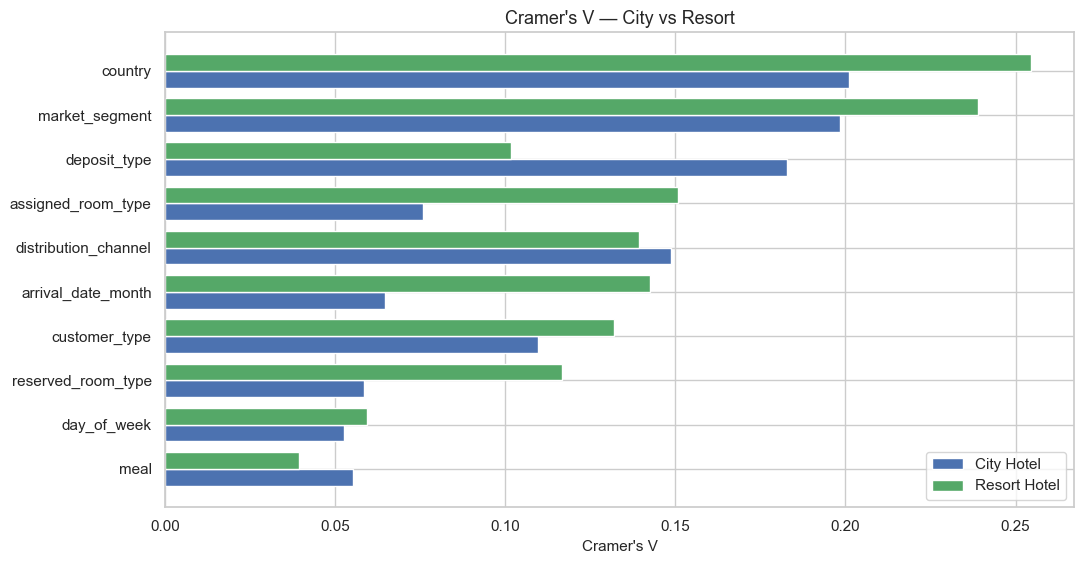

In [9]:
rows = []
for h in HOTELS:
    t = tables[h]["cramers"]
    for _, r in t.iterrows():
        if r["variable"] in KEY_CAT:
            rows.append({"hotel": h, "variable": r["variable"], "V": r["cramers_v"]})
cr_df = pd.DataFrame(rows)
corder = cr_df.groupby("variable")["V"].max().sort_values(ascending=True).index.tolist()
y = np.arange(len(corder))
fig, ax = plt.subplots(figsize=(11, 5.8))
for i, h in enumerate(HOTELS):
    vals = [cr_df[(cr_df.hotel == h) & (cr_df.variable == v)]["V"].iloc[0] for v in corder]
    ax.barh(y + (i - 0.5) * w, vals, height=w, color=HOTEL_COLORS[h], label=h)
ax.set_yticks(y)
ax.set_yticklabels(corder)
ax.set_xlabel("Cramer's V")
ax.set_title("Cramer's V — City vs Resort")
ax.legend()
savefig("03_cramers_compare.png")
plt.show()


## 3. Heatmap Pearson (loại leakage)

Cùng tập biến then chốt, hai hotel cạnh nhau để so cấu trúc tương quan — không chỉ cột target.


Saved: reports\figures\04b\04_heatmap_pearson.png


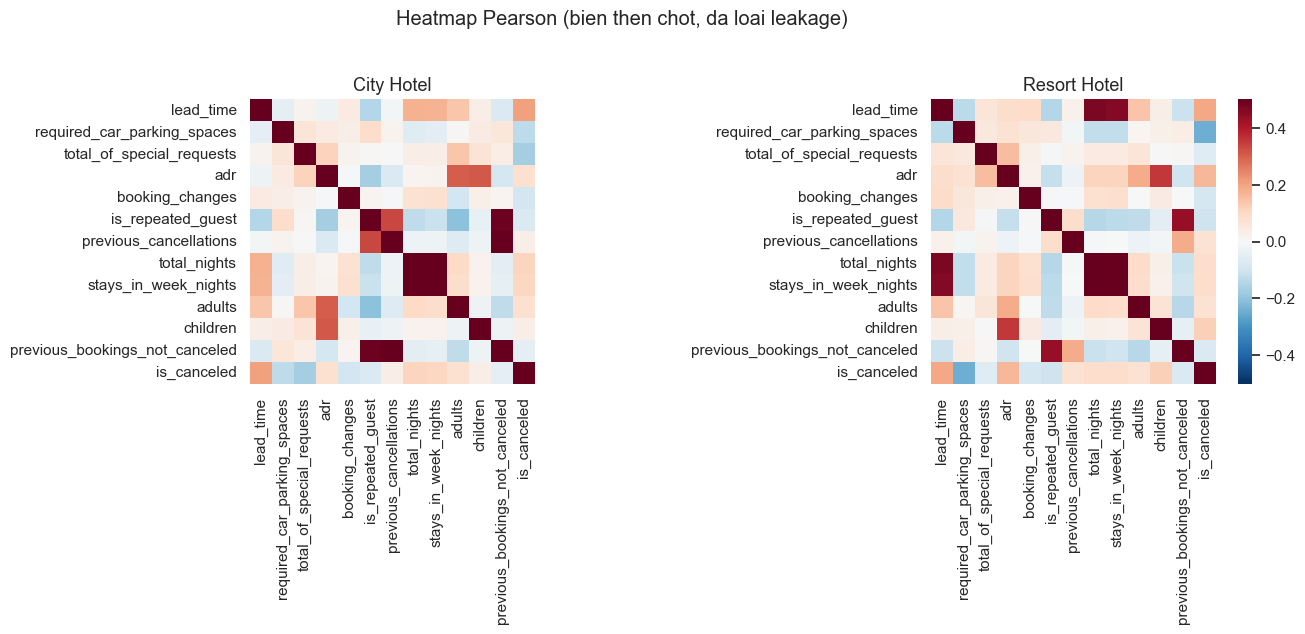

In [10]:
heat_vars = [c for c in KEY_NUM if c in df.columns] + [TARGET]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for ax, h in zip(axes, HOTELS):
    corr = df.loc[df["hotel"] == h, heat_vars].corr()
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5, square=True, cbar=(h == HOTELS[-1]))
    ax.set_title(h)
fig.suptitle("Heatmap Pearson (bien then chot, da loai leakage)", y=1.02)
savefig("04_heatmap_pearson.png")
plt.show()


Saved: reports\figures\04b\05_heatmap_target.png


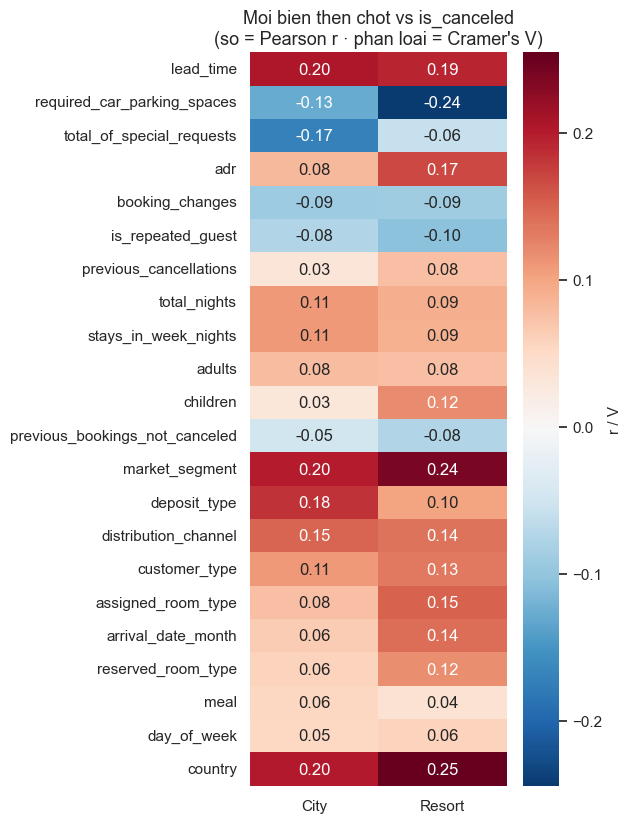

In [11]:
labels = KEY_NUM + KEY_CAT
mat = []
for h in HOTELS:
    pear = tables[h]["pearson"].set_index("variable")["pearson"]
    cram = tables[h]["cramers"].set_index("variable")["cramers_v"]
    col = [pear[c] if c in pear.index else cram.get(c, np.nan) for c in labels]
    mat.append(col)
heat = pd.DataFrame(np.array(mat).T, index=labels, columns=["City", "Resort"])
fig, ax = plt.subplots(figsize=(6.2, 8.4))
sns.heatmap(heat, ax=ax, cmap="RdBu_r", center=0, annot=True, fmt=".2f", cbar_kws={"label": "r / V"})
ax.set_title("Moi bien then chot vs is_canceled\n(so = Pearson r · phan loai = Cramer's V)")
savefig("05_heatmap_target.png")
plt.show()


## 4. Leakage — loại khỏi modeling

Cùng danh sách với notebook 04. `reservation_status` V = 1 ở **cả hai** hotel (nhãn hủy).
`revenue = adr × total_nights × (1 − is_canceled)` — tương quan cơ học, biên độ City mạnh hơn vì ADR cao hơn.


hotel,City Hotel,Resort Hotel
variable,,
Occupancy_Rate,-0.130,-0.173
RevPAR,0.006,0.140
reservation_status,1.000,1.000
reservation_status_date,0.321,0.378
revenue,-0.610,-0.422


Saved: reports\figures\04b\06_leakage.png


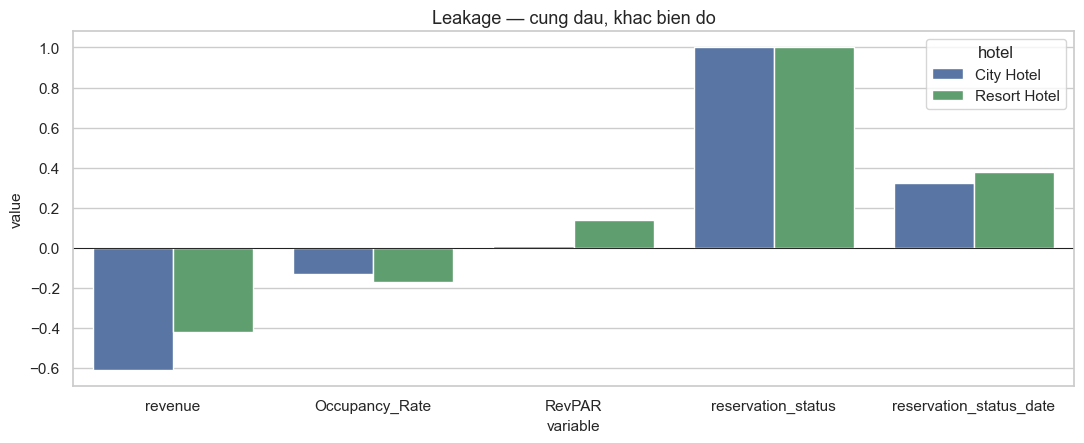

In [12]:
leak_rows = []
for h in HOTELS:
    d = df[df["hotel"] == h]
    for c in LEAK_NUM:
        sub = d[[c, TARGET]].dropna()
        r = float(pearsonr(sub[c], sub[TARGET])[0]) if len(sub) > 10 else np.nan
        leak_rows.append({"hotel": h, "variable": c, "metric": "Pearson r", "value": r})
    for c in LEAK_CAT:
        leak_rows.append({"hotel": h, "variable": c, "metric": "Cramer's V", "value": cramers_v(d[c], d[TARGET])})
leak_df = pd.DataFrame(leak_rows)
display(leak_df.pivot(index="variable", columns="hotel", values="value").style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(11, 4.6))
sns.barplot(data=leak_df, x="variable", y="value", hue="hotel", hue_order=HOTELS, palette=HOTEL_COLORS, ax=ax)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Leakage — cung dau, khac bien do")
savefig("06_leakage.png")
plt.show()


## 5. Partial correlation — `lead_time` ↔ `deposit_type`

Encode `No Deposit=0`, `Refundable=1`, `Non Refund=2`. Residual OLS giống notebook 04.


,hotel,pearson_lead_raw,partial_lead_ctrl_deposit,partial_deposit_ctrl_lead
0,City Hotel,0.204,0.169,0.142
1,Resort Hotel,0.193,0.187,0.085


Saved: reports\figures\04b\07_partial_corr.png


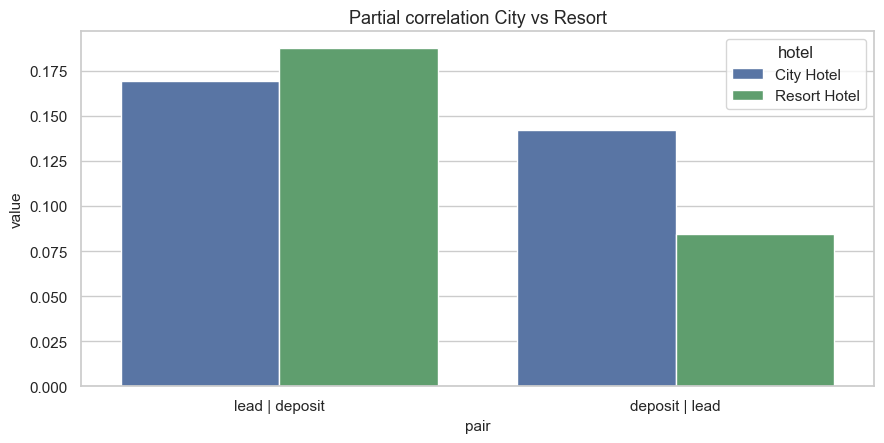

Lead van duong sau khi kiem soat deposit o ca hai hotel.
Deposit con hieu ung sau lead — City manh hon (khop 05c V 0.183 vs 0.102).


In [13]:
part_rows = []
for h in HOTELS:
    d = df[df["hotel"] == h].copy()
    d["dep_enc"] = d["deposit_type"].map(DEP_MAP)
    raw_lead = float(pearsonr(d["lead_time"], d[TARGET])[0])
    pc_lead = partial_corr("lead_time", TARGET, ["dep_enc"], d)
    pc_dep = partial_corr("dep_enc", TARGET, ["lead_time"], d)
    part_rows.append({
        "hotel": h,
        "pearson_lead_raw": raw_lead,
        "partial_lead_ctrl_deposit": pc_lead,
        "partial_deposit_ctrl_lead": pc_dep,
    })
part = pd.DataFrame(part_rows)
display(part.style.format("{:.3f}", subset=[c for c in part.columns if c != "hotel"]))

long = []
for r in part_rows:
    long.append({"hotel": r["hotel"], "pair": "lead | deposit", "value": r["partial_lead_ctrl_deposit"]})
    long.append({"hotel": r["hotel"], "pair": "deposit | lead", "value": r["partial_deposit_ctrl_lead"]})
fig, ax = plt.subplots(figsize=(9, 4.6))
sns.barplot(data=pd.DataFrame(long), x="pair", y="value", hue="hotel", hue_order=HOTELS, palette=HOTEL_COLORS, ax=ax)
ax.set_title("Partial correlation City vs Resort")
savefig("07_partial_corr.png")
plt.show()

print("Lead van duong sau khi kiem soat deposit o ca hai hotel.")
print("Deposit con hieu ung sau lead — City manh hon (khop 05c V 0.183 vs 0.102).")


## 6. Causation vs correlation — tier theo hotel

Quy ước giữ như 04: correlation ≠ causation. Tier **có thể đổi hạng** khi tách hotel.

| Tier | City | Resort |
|---|---|---|
| 1 — can thiệp | `lead_time`, `deposit_type` | `lead_time`, `required_car_parking_spaces` |
| 2 — feature + lever gián tiếp | `market_segment`, special requests, channel | `market_segment`, month, assigned room, channel |
| 3 — confounded | `adr` (yếu), `total_nights` | `adr` (mạnh hơn), `agent`, `children` |
| Leakage | giống 04 | giống 04 |

`deposit_type` vẫn candidate causation ở Resort nhưng **effect nhỏ hơn** (partial 0,08 vs 0,14).
Parking mạnh ở Resort vì khách nghỉ dưỡng thường đi xe — tín hiệu cam kết, không phải lever giá.


Saved: reports\figures\04b\08_signal_weights.png


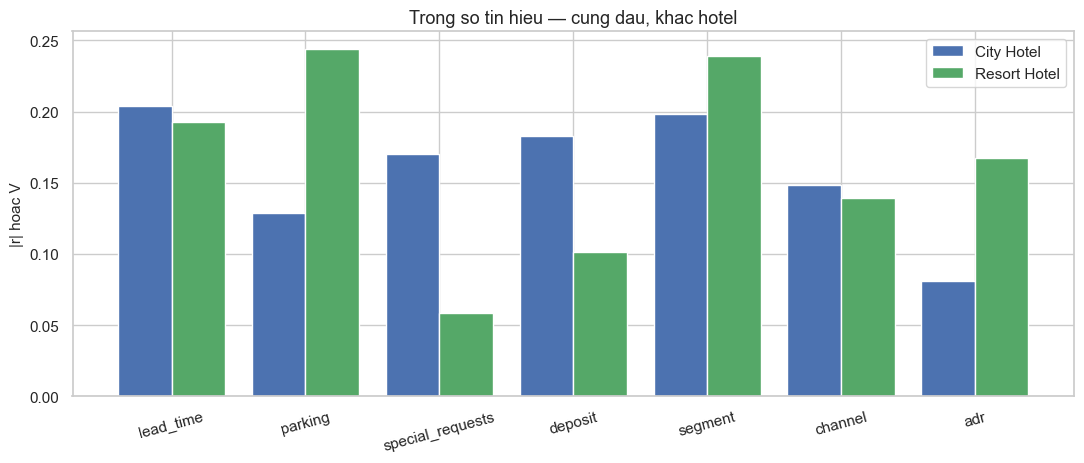

In [14]:
feat = ["lead_time", "parking", "special_requests", "deposit", "segment", "channel", "adr"]
city_v, res_v = [], []
for h, bucket in [("City Hotel", city_v), ("Resort Hotel", res_v)]:
    pear = tables[h]["pearson"].set_index("variable")
    cram = tables[h]["cramers"].set_index("variable")
    bucket.extend([
        pear.loc["lead_time", "pearson"],
        abs(pear.loc["required_car_parking_spaces", "pearson"]),
        abs(pear.loc["total_of_special_requests", "pearson"]),
        cram.loc["deposit_type", "cramers_v"],
        cram.loc["market_segment", "cramers_v"],
        cram.loc["distribution_channel", "cramers_v"],
        abs(pear.loc["adr", "pearson"]),
    ])
x = np.arange(len(feat))
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(x - 0.2, city_v, 0.4, color=HOTEL_COLORS["City Hotel"], label="City Hotel")
ax.bar(x + 0.2, res_v, 0.4, color=HOTEL_COLORS["Resort Hotel"], label="Resort Hotel")
ax.set_xticks(x)
ax.set_xticklabels(feat, rotation=15)
ax.set_ylabel("|r| hoac V")
ax.set_title("Trong so tin hieu — cung dau, khac hotel")
ax.legend()
savefig("08_signal_weights.png")
plt.show()


## 7. Bảng so sánh + export


In [15]:
cmp_rows = []
for c in KEY_NUM:
    pc = tables["City Hotel"]["pearson"].set_index("variable")
    pr = tables["Resort Hotel"]["pearson"].set_index("variable")
    cmp_rows.append({
        "variable": c, "type": "numeric",
        "city_pearson": pc.loc[c, "pearson"] if c in pc.index else np.nan,
        "resort_pearson": pr.loc[c, "pearson"] if c in pr.index else np.nan,
        "city_spearman": pc.loc[c, "spearman"] if c in pc.index else np.nan,
        "resort_spearman": pr.loc[c, "spearman"] if c in pr.index else np.nan,
        "delta_pearson": (
            (pc.loc[c, "pearson"] - pr.loc[c, "pearson"]) if c in pc.index and c in pr.index else np.nan
        ),
    })
for c in KEY_CAT:
    cc = tables["City Hotel"]["cramers"].set_index("variable")["cramers_v"]
    rc = tables["Resort Hotel"]["cramers"].set_index("variable")["cramers_v"]
    cmp_rows.append({
        "variable": c, "type": "categorical",
        "city_cramers": cc.get(c, np.nan),
        "resort_cramers": rc.get(c, np.nan),
        "delta_cramers": (cc.get(c, np.nan) - rc.get(c, np.nan)),
    })
cmp = pd.DataFrame(cmp_rows)
display(cmp.style.format("{:.3f}", subset=[c for c in cmp.columns if c not in ("variable", "type")]))
cmp.to_csv(FIG_DIR / "corr_compare_city_resort.csv", index=False)
print(f"Saved: {(FIG_DIR / 'corr_compare_city_resort.csv').relative_to(ROOT)}")


,variable,type,city_pearson,resort_pearson,city_spearman,resort_spearman,delta_pearson,city_cramers,resort_cramers,delta_cramers
0,lead_time,numeric,0.204,0.193,0.226,0.244,0.011,nan,nan,nan
1,required_car_parking_spaces,numeric,-0.129,-0.244,-0.129,-0.248,0.115,nan,nan,nan
2,total_of_special_requests,numeric,-0.170,-0.059,-0.182,-0.059,-0.111,nan,nan,nan
3,adr,numeric,0.081,0.168,0.095,0.166,-0.086,nan,nan,nan
4,booking_changes,numeric,-0.091,-0.090,-0.127,-0.111,-0.001,nan,nan,nan
5,is_repeated_guest,numeric,-0.075,-0.105,-0.075,-0.105,0.029,nan,nan,nan
6,previous_cancellations,numeric,0.033,0.077,0.120,0.120,-0.044,nan,nan,nan
7,total_nights,numeric,0.110,0.093,0.094,0.128,0.017,nan,nan,nan
8,stays_in_week_nights,numeric,0.109,0.091,0.093,0.119,0.018,nan,nan,nan
9,adults,numeric,0.079,0.076,0.082,0.086,0.003,nan,nan,nan


Saved: reports\figures\04b\corr_compare_city_resort.csv


## 8. Kết luận cho modeling

- **Cùng dấu với bản gộp 04:** lead dương, parking / special requests âm, segment & deposit liên kết với hủy, leakage y nguyên.
- **Sai trọng số nếu không tách hotel:** deposit và special requests mạnh ở City; parking, segment, ADR/tháng mạnh ở Resort.
- Partial: lead vẫn độc lập với deposit ở cả hai; residual deposit **lớn hơn hẳn ở City**.
- Feature P1 City: `lead_time`, `deposit_type`, `market_segment`, `total_of_special_requests`.
- Feature P1 Resort: `lead_time`, `required_car_parking_spaces`, `market_segment`, `arrival_date_month` (confounded — dùng FE chứ không coi là lever hủy).
- Không dùng: `reservation_status`, `revenue`, Occupancy, RevPAR. Không dùng `hotel` trong model đã stratify.
